# ModelPipeline & SmartRouter Deep Dive
# ModelPipeline 与 SmartRouter 深度指南

This tutorial is a comprehensive guide to the two core orchestration engines of PipelineTS:
本教程是 PipelineTS 两大核心编排引擎的全面指南：

- **ModelPipeline** — Train, evaluate, and compare multiple models with a unified API.
- **ModelPipeline** — 使用统一接口训练、评估和比较多个模型。

- **SmartRouter** — Intelligent AutoML that automatically profiles data, selects models, tunes hyperparameters, and builds ensembles.
- **SmartRouter** — 智能 AutoML，自动进行数据画像、模型选择、超参数调优和集成构建。

---

**Table of Contents / 目录:**

### Part I: ModelPipeline / 第一部分：ModelPipeline
1. Basic usage / 基本用法
2. Model filtering (`include_models`, `exclude_models`) / 模型筛选
3. Double-underscore syntax / 双下划线语法
4. PipelineConfigs / 管道配置
5. Custom scaler & metric / 自定义缩放器与指标
6. Leaderboard & model access / 排行榜与模型访问
7. Prediction intervals (`quantile`) / 预测区间
8. Multi-quantile output / 多分位数输出
9. Multi-series panel data (`id_col`) / 多序列面板数据
10. Covariates / 协变量
11. Incremental learning (`update`) / 增量学习
12. Time budget / 时间预算
13. Visualization / 可视化
14. Error resilience / 错误容错
15. Save & Load / 保存与加载

### Part II: SmartRouter / 第二部分：SmartRouter
16. Basic usage / 基本用法
17. Presets / 预设模式
18. Data profiling / 数据画像
19. Model scoring & selection / 模型评分与选择
20. Lag exploration / 滞后窗口探索
21. HPO (Optuna) / 超参数优化
22. Ensemble strategies / 集成策略
23. Search strategies / 搜索策略
24. SmartRouter with panel data & covariates / 面板数据与协变量
25. SmartRouter visualization & incremental update / 可视化与增量更新
26. Full production example / 完整生产示例

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Generate example data / 生成示例数据
np.random.seed(42)
n = 200
dates = pd.date_range(start='2020-01-01', periods=n, freq='D')
values = 50 + 10 * np.sin(np.linspace(0, 6 * np.pi, n)) + np.random.randn(n) * 2
data = pd.DataFrame({'date': dates, 'value': values})

print(f"Data: {data.shape[0]} rows, {data['date'].min().date()} ~ {data['date'].max().date()}")
data.head()

Data: 200 rows, 2020-01-01 ~ 2020-07-18


,date,value
0,2020-01-01,50.993428
1,2020-01-02,50.669269
2,2020-01-03,53.178494
3,2020-01-04,55.849612
4,2020-01-05,53.230546


---
# Part I: ModelPipeline
# 第一部分：ModelPipeline

ModelPipeline is the workhorse: it takes a list of models, trains each on the same data with cross-validation, ranks them, and provides a single `predict()` call.

ModelPipeline 是核心工具：接收模型列表，在相同数据上以交叉验证训练每个模型，排名后提供统一 `predict()` 调用。

## 1. Basic Usage / 基本用法

In [2]:
from PipelineTS.pipeline import ModelPipeline

pipeline = ModelPipeline(
    time_col='date',
    target_col='value',
    lags=12,              # Input window size / 输入窗口大小
    include_models='ml',  # Use ML models (fast) / 使用 ML 模型（快速）
    quantile=0.9,         # 90% prediction interval / 90% 预测区间
    cv=3,                 # 3-fold cross validation / 3 折交叉验证
)

leaderboard = pipeline.fit(data)
leaderboard


2026-02-13 11:21:36 - ModelPipeline - INFO - Accelerator: CPU
2026-02-13 11:21:36 - ModelPipeline - INFO - Training 7 models: ['catboost', 'lightgbm', 'multi_output_model', 'multi_step_model', 'random_forest', 'wide_gbrt', 'xgboost']
2026-02-13 11:21:36 - ModelPipeline - INFO - [1/7] Fitting catboost...
2026-02-13 11:21:49 - ModelPipeline - INFO -   => catboost: metric=14.143339, train=9.82s, eval=0.27s, quantile_acc=0.500
2026-02-13 11:21:49 - ModelPipeline - INFO - [2/7] Fitting lightgbm...
2026-02-13 11:21:59 - ModelPipeline - INFO -   => lightgbm: metric=14.175935, train=6.33s, eval=0.28s, quantile_acc=0.667
2026-02-13 11:21:59 - ModelPipeline - INFO - [3/7] Fitting multi_output_model...
2026-02-13 11:22:04 - ModelPipeline - INFO -   => multi_output_model: metric=13.302545, train=1.84s, eval=0.24s, quantile_acc=0.458
2026-02-13 11:22:04 - ModelPipeline - INFO - [4/7] Fitting multi_step_model...
2026-02-13 11:22:09 - ModelPipeline - INFO -   => multi_step_model: metric=13.843199, t

Leaderboard,model,train_cost(s),eval_cost(s),metric,quantile_acc
0,wide_gbrt,13.633624,1.200191,11.664020,0.791667
1,multi_output_model,1.842380,0.238050,13.302545,0.458333
2,multi_step_model,1.192323,0.233886,13.843199,0.500000
3,xgboost,6.174657,0.222732,13.865766,0.666667
4,random_forest,5.740382,1.547730,14.048619,0.458333
5,catboost,9.823147,0.265277,14.143339,0.500000
6,lightgbm,6.331398,0.281775,14.175935,0.666667


In [3]:
# Predict with the best model / 使用最佳模型预测
result = pipeline.predict(n=15)
print(f"Best model / 最佳模型: {leaderboard.iloc[0]['model']}")
result.head()

Best model / 最佳模型: wide_gbrt


,date,value,value_lower,value_upper
0,2020-07-19,51.456233,36.079321,58.910831
1,2020-07-20,48.459938,33.083026,55.914537
2,2020-07-21,50.305719,34.928807,57.760318
3,2020-07-22,51.606872,36.229960,59.061470
4,2020-07-23,52.876653,37.499741,60.331251


## 2. Model Filtering / 模型筛选

Control which models to train via `include_models` or `exclude_models`.

通过 `include_models` 或 `exclude_models` 控制训练哪些模型。

In [4]:
# View all available models / 查看所有可用模型
all_models = ModelPipeline.list_all_available_models()
print(f"Total models / 模型总数: {len(all_models)}")
print(all_models)

Total models / 模型总数: 28
['auto_arima', 'catboost', 'chronos_2', 'chronos_2_small', 'chronos_2_synth', 'd_linear', 'deepar', 'gau', 'itransformer', 'lightgbm', 'multi_output_model', 'multi_step_model', 'n_beats', 'n_hits', 'n_linear', 'patch_rnn', 'prophet', 'random_forest', 'regressor_chain', 'srs_net', 'stacking_rnn', 'tcn', 'tft', 'tide', 'time2vec', 'transformer', 'wide_gbrt', 'xgboost']


In [ ]:
# Predefined model sets / 预定义模型集合
sets = {
    "'light' (default)": 'light',  # Balanced speed/quality / 速度与质量平衡
    "'ml'": 'ml',                  # GBDT + ensemble ML only / 仅 GBDT + 集成 ML
    "'nn'": 'nn',                  # Neural networks only / 仅神经网络
    "'all'": 'all',                # All models / 全部模型
}

for label, mode in sets.items():
    p = ModelPipeline(time_col='date', target_col='value', lags=12, include_models=mode)
    print(f"{label:20s} -> {len(p._given_models or [])} models")

# Custom list / 自定义列表
# include_models=['torch_boosting_forest', 'prophet', 'n_linear', 'tft']

'light' (default)    -> 11 models
'ml'                 -> 7 models
'nn'                 -> 15 models
'all'                -> 0 models


## 3. Double-Underscore Syntax / 双下划线语法

Pass model-specific parameters via `model_name__param=value`.

通过 `模型名__参数名=值` 传递模型特定参数。

In [ ]:
pipeline_custom = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest', 'torch_bagging_forest', 'n_linear'],
    quantile=None, cv=2,
    # Model-specific params / 模型专属参数
    torch_boosting_forest__n_trees=64,
    torch_bagging_forest__n_trees=128,
    n_linear__epochs=200,
    n_linear__patience=20,
    n_linear__verbose=False,
    n_linear__learning_rate=0.001,
    n_linear__use_gtb=True,
    n_linear__routing_mode="adaptive"
)
pipeline_custom.fit(data)


2026-02-13 11:22:47 - ModelPipeline - INFO - Accelerator: MPS
2026-02-13 11:22:48 - ModelPipeline - INFO - Training 3 models: ['lightgbm', 'n_linear', 'xgboost']
2026-02-13 11:22:48 - ModelPipeline - INFO - [1/3] Fitting lightgbm...
2026-02-13 11:22:55 - ModelPipeline - INFO -   => lightgbm: metric=14.175935, train=3.18s, eval=0.28s
2026-02-13 11:22:55 - ModelPipeline - INFO - [2/3] Fitting n_linear...
2026-02-13 11:23:25 - ModelPipeline - INFO -   => n_linear: metric=6.750729, train=26.89s, eval=0.49s
2026-02-13 11:23:25 - ModelPipeline - INFO - [3/3] Fitting xgboost...
2026-02-13 11:23:33 - ModelPipeline - INFO -   => xgboost: metric=13.865766, train=3.76s, eval=0.25s
2026-02-13 11:23:33 - ModelPipeline - INFO - 
Training complete: 3 succeeded, 0 failed, 0 skipped (45.2s total)
2026-02-13 11:23:33 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -----------------------------------------------------------------------------
 *

Leaderboard,model,train_cost(s),eval_cost(s),metric
0,n_linear,26.894924,0.491428,6.750729
1,xgboost,3.755801,0.246168,13.865766
2,lightgbm,3.176677,0.280877,14.175935


## 4. PipelineConfigs / 管道配置

Create multiple variants of the same model with different hyperparameters.

为同一模型创建多个不同超参数的变体。

In [ ]:
from PipelineTS.pipeline import PipelineConfigs

configs = PipelineConfigs([
    ('torch_boosting_forest', 'boost_fast', {
        'init_configs': {'n_trees': 16},
        'fit_configs': {}
    }),
    ('torch_boosting_forest', 'boost_deep', {
        'init_configs': {'n_trees': 128, 'tree_depth': 7},
        'fit_configs': {}
    }),
])

pipe_conf = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest'], configs=configs,
    quantile=None, cv=2,
)
pipe_conf.fit(data)

,model_name,model_name_after_rename,model_configs
0,lightgbm,lgbm_fast,"{'init_configs': {'n_estimators': 50}, 'fit_configs': {}, 'predict_configs': {}}"
1,lightgbm,lgbm_deep,"{'init_configs': {'n_estimators': 500, 'max_depth': 10}, 'fit_configs': {}, 'predict_configs': {}}"



2026-02-13 11:23:33 - ModelPipeline - INFO - Accelerator: CPU
2026-02-13 11:23:33 - ModelPipeline - INFO - Training 2 models: ['lgbm_fast', 'lgbm_deep']
2026-02-13 11:23:33 - ModelPipeline - INFO - [1/2] Fitting lgbm_fast...
2026-02-13 11:23:38 - ModelPipeline - INFO -   => lgbm_fast: metric=12.903407, train=1.73s, eval=0.29s
2026-02-13 11:23:38 - ModelPipeline - INFO - [2/2] Fitting lgbm_deep...
2026-02-13 11:23:47 - ModelPipeline - INFO -   => lgbm_deep: metric=14.175195, train=5.73s, eval=0.29s
2026-02-13 11:23:47 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 0 skipped (14.6s total)
2026-02-13 11:23:47 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -----------------------------------------------------------------------------
 *1    lgbm_fast                       1.7253       0.2879      12.9034 
  2    lgbm_deep                       5.7281       0.2898      14.1752 


Leaderboard,model,train_cost(s),eval_cost(s),metric
0,lgbm_fast,1.725326,0.287939,12.903407
1,lgbm_deep,5.728145,0.289766,14.175195


## 5. Custom Scaler & Metric / 自定义缩放器与指标

In [ ]:
from sklearn.preprocessing import StandardScaler
from PipelineTS.spinesTS.metrics import rmse

pipe_custom = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest', 'torch_bagging_forest'],
    scaler=StandardScaler(),         # Custom scaler / 自定义缩放器
    metric=rmse,                      # RMSE instead of MAE / 使用 RMSE 替代 MAE
    metric_less_is_better=True,
    quantile=None, cv=2,
)
pipe_custom.fit(data)


2026-02-13 11:23:47 - ModelPipeline - INFO - Accelerator: CPU
2026-02-13 11:23:47 - ModelPipeline - INFO - Training 2 models: ['lightgbm', 'xgboost']
2026-02-13 11:23:47 - ModelPipeline - INFO - [1/2] Fitting lightgbm...
2026-02-13 11:23:59 - ModelPipeline - INFO -   => lightgbm: metric=14.634381, train=7.70s, eval=0.29s
2026-02-13 11:23:59 - ModelPipeline - INFO - [2/2] Fitting xgboost...
2026-02-13 11:24:07 - ModelPipeline - INFO -   => xgboost: metric=14.761185, train=4.99s, eval=0.24s
2026-02-13 11:24:07 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 0 skipped (19.8s total)
2026-02-13 11:24:07 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -----------------------------------------------------------------------------
 *1    lightgbm                        7.6959       0.2874      14.6344 
  2    xgboost                         4.9925       0.2424      14.7612 


Leaderboard,model,train_cost(s),eval_cost(s),metric
0,lightgbm,7.695880,0.287379,14.634381
1,xgboost,4.992547,0.242412,14.761185


## 6. Leaderboard & Model Access / 排行榜与模型访问

In [9]:
# Leaderboard is a DataFrame / 排行榜是 DataFrame
print("Leaderboard columns / 排行榜列名:", pipeline.leader_board_.columns.tolist())
print()

# Get the best trained model object / 获取最佳已训练模型对象
best_model = pipeline.get_model()
print(f"Best model type / 最佳模型类型: {type(best_model).__name__}")

# Get a specific model / 获取指定模型
second_model_name = pipeline.leader_board_.iloc[1]['model']
specific_model = pipeline.get_model(second_model_name)
print(f"Second model / 第二模型: {second_model_name}")

# Get all configs / 获取全部配置
configs = pipeline.get_model_all_configs()
print(f"Config keys / 配置键: {list(configs.keys())[:5]}...")

Leaderboard columns / 排行榜列名: ['model', 'train_cost(s)', 'eval_cost(s)', 'metric', 'quantile_acc']

Best model type / 最佳模型类型: WideGBRTModel
Second model / 第二模型: multi_output_model
Config keys / 配置键: ['model_configs', 'lags', 'quantile', 'time_col', 'target_col']...


In [10]:
# Predict with a specific model / 使用指定模型预测
result_second = pipeline.predict(n=10, model_name=second_model_name)
result_second.head()

,date,value,value_lower,value_upper
0,2020-07-19,49.519938,35.631271,58.498176
1,2020-07-20,49.335813,35.447146,58.314051
2,2020-07-21,49.878297,35.989630,58.856534
3,2020-07-22,51.347577,37.458910,60.325815
4,2020-07-23,51.304770,37.416103,60.283008


## 7. Prediction Intervals / 预测区间

In [11]:
# quantile=0.9 was set at init → predict returns _lower/_upper columns
# quantile=0.9 在初始化时设置 → predict 返回 _lower/_upper 列
result_interval = pipeline.predict(15)
print("Columns / 列名:", result_interval.columns.tolist())
result_interval.head()

Columns / 列名: ['date', 'value', 'value_lower', 'value_upper']


,date,value,value_lower,value_upper
0,2020-07-19,51.456233,36.079321,58.910831
1,2020-07-20,48.459938,33.083026,55.914537
2,2020-07-21,50.305719,34.928807,57.760318
3,2020-07-22,51.606872,36.229960,59.061470
4,2020-07-23,52.876653,37.499741,60.331251


## 8. Multi-Quantile Output / 多分位数输出

In [12]:
# Predict at multiple coverage levels simultaneously
# 同时预测多个覆盖水平
result_mq = pipeline.predict_quantiles(n=10, levels=[0.5, 0.8, 0.95])
print("Multi-quantile columns / 多分位数列:")
for c in result_mq.columns:
    print(f"  {c}")
result_mq.head()

Multi-quantile columns / 多分位数列:
  date
  value
  value_q0.5_lower
  value_q0.5_upper
  value_q0.8_lower
  value_q0.8_upper
  value_q0.95_lower
  value_q0.95_upper


,date,value,value_q0.5_lower,value_q0.5_upper,value_q0.8_lower,value_q0.8_upper,value_q0.95_lower,value_q0.95_upper
0,2020-07-19,51.456233,45.004630,53.490960,38.980744,56.447060,34.491013,63.291827
1,2020-07-20,48.459938,42.008335,50.494665,35.984449,53.450765,31.494719,60.295533
2,2020-07-21,50.305719,43.854116,52.340446,37.830230,55.296547,33.340500,62.141314
3,2020-07-22,51.606872,45.155269,53.641599,39.131383,56.597699,34.641653,63.442466
4,2020-07-23,52.876653,46.425050,54.911380,40.401164,57.867480,35.911434,64.712247


## 9. Multi-Series Panel Data / 多序列面板数据

In [ ]:
# Create panel data / 创建面板数据
panel_dfs = []
for sid in ['A', 'B', 'C']:
    v = np.random.uniform(30, 70) + 8 * np.sin(np.linspace(0, 4*np.pi, 150)) + np.random.randn(150)*2
    panel_dfs.append(pd.DataFrame({
        'date': pd.date_range('2020-01-01', periods=150, freq='D'),
        'value': v, 'store': sid
    }))
panel_data = pd.concat(panel_dfs, ignore_index=True)

pipe_panel = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    id_col='store',                  # Panel mode / 面板模式
    include_models=['torch_boosting_forest'],
    quantile=0.9, cv=2,
)
pipe_panel.fit(panel_data)
panel_pred = pipe_panel.predict(n=5)

print(f"Panel prediction: {panel_pred.shape[0]} rows, stores: {panel_pred['store'].unique().tolist()}")
panel_pred


2026-02-13 11:24:08 - ModelPipeline - INFO - Accelerator: CPU
2026-02-13 11:24:08 - ModelPipeline - INFO - Multi-series mode: 3 series detected (id_col='store')
2026-02-13 11:24:08 - ModelPipeline - INFO - Training 1 models: ['lightgbm']
2026-02-13 11:24:08 - ModelPipeline - INFO - [1/1] Fitting lightgbm...
2026-02-13 11:24:26 - ModelPipeline - INFO -   => lightgbm: metric=11.151272, train=14.60s, eval=0.46s, quantile_acc=0.458
2026-02-13 11:24:26 - ModelPipeline - INFO - 
Training complete: 1 succeeded, 0 failed, 0 skipped (18.4s total)
2026-02-13 11:24:26 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric     QAcc 
  --------------------------------------------------------------------------------------
 *1    lightgbm                       14.6022       0.4556      11.1513       0.4583 


Panel prediction: 15 rows, stores: ['A', 'B', 'C']


,date,value,value_lower,value_upper,store
0,2020-05-30,52.900050,41.912035,61.734942,A
1,2020-05-31,53.437189,42.449174,62.272081,A
2,2020-06-01,53.764986,42.776971,62.599878,A
3,2020-06-02,54.491678,43.503663,63.326569,A
4,2020-06-03,56.112571,45.124556,64.947462,A
5,2020-05-30,39.837234,27.178252,50.015664,B
6,2020-05-31,42.719727,30.060745,52.898157,B
7,2020-06-01,43.184002,30.525019,53.362432,B
8,2020-06-02,44.863110,32.204127,55.041540,B
9,2020-06-03,43.410437,30.751454,53.588867,B


## 10. Covariates / 协变量

In [ ]:
# Add covariates to data / 向数据添加协变量
cov_data = data.copy()
cov_data['holiday'] = np.random.choice([0, 1], size=len(data), p=[0.9, 0.1])
cov_data['temperature'] = 15 + 10 * np.sin(np.linspace(0, 2*np.pi, len(data))) + np.random.randn(len(data))

pipe_cov = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    known_covariates=['holiday'],         # Future known / 未来已知
    past_covariates=['temperature'],      # Historical only / 仅历史
    include_models=['torch_boosting_forest', 'prophet'],
    quantile=0.9, cv=2,
)
pipe_cov.fit(cov_data)

# Provide future covariates at predict time / 预测时提供未来协变量
future = pd.DataFrame({'holiday': [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]})
pipe_cov.predict(n=10, future_covariates=future).head()


2026-02-13 11:24:26 - ModelPipeline - INFO - Accelerator: CPU
2026-02-13 11:24:26 - ModelPipeline - INFO - Training 2 models: ['lightgbm', 'prophet']
2026-02-13 11:24:26 - ModelPipeline - INFO - [1/2] Fitting lightgbm...
2026-02-13 11:24:39 - ModelPipeline - INFO -   => lightgbm: metric=13.989739, train=9.50s, eval=0.29s, quantile_acc=0.542
2026-02-13 11:24:39 - ModelPipeline - INFO - [2/2] Fitting prophet...
2026-02-13 11:24:44 - ModelPipeline - INFO -   => prophet: metric=13.889544, train=1.11s, eval=0.20s, quantile_acc=0.458
2026-02-13 11:24:44 - ModelPipeline - INFO - 
Training complete: 2 succeeded, 0 failed, 0 skipped (17.7s total)
2026-02-13 11:24:44 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric     QAcc 
  --------------------------------------------------------------------------------------
 *1    prophet                         1.1133       0.2026      13.8895       0.4583 
  2    lightgbm                        9.49

,date,value,value_lower,value_upper
0,2020-07-19,50.779160,36.643208,78.011472
1,2020-07-20,53.114027,38.978075,80.346339
2,2020-07-21,53.345976,39.210023,80.578287
3,2020-07-22,54.175399,40.039447,81.407711
4,2020-07-23,55.590705,41.454753,82.823017


## 11. Incremental Learning / 增量学习

In [ ]:
# Initial fit / 初始训练
pipe_inc = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models=['torch_boosting_forest'], quantile=None, cv=2,
)
pipe_inc.fit(data.iloc[:150])
print("Before update / 更新前:", pipe_inc.predict(3)['value'].values)

# Incremental update / 增量更新
pipe_inc.update(data.iloc[150:])
print("After update / 更新后: ", pipe_inc.predict(3)['value'].values)


2026-02-13 11:24:44 - ModelPipeline - INFO - Accelerator: CPU
2026-02-13 11:24:44 - ModelPipeline - INFO - Training 1 models: ['lightgbm']
2026-02-13 11:24:44 - ModelPipeline - INFO - [1/1] Fitting lightgbm...
2026-02-13 11:24:52 - ModelPipeline - INFO -   => lightgbm: metric=9.862857, train=4.58s, eval=0.29s
2026-02-13 11:24:52 - ModelPipeline - INFO - 
Training complete: 1 succeeded, 0 failed, 0 skipped (8.2s total)
2026-02-13 11:24:52 - ModelPipeline - INFO - 
  Rank  Model                       train_cost(s)    eval_cost(s)       Metric 
  -----------------------------------------------------------------------------
 *1    lightgbm                        4.5800       0.2888       9.8629 


Before update / 更新前: [59.53766088 58.29615255 59.80976822]



2026-02-13 11:24:57 - ModelPipeline - INFO -   Updated: lightgbm


After update / 更新后:  [50.70968812 49.38080167 52.85280139]


## 12. Time Budget / 时间预算

In [16]:
pipe_timed = ModelPipeline(
    time_col='date', target_col='value', lags=12,
    include_models='ml',
    time_limit=30,         # 30 seconds total budget / 总共 30 秒预算
    quantile=None, cv=2,
)
pipe_timed.fit(data)

print(f"Completed models / 完成的模型: {len(pipe_timed.leader_board_)}")
print(f"Failed / 失败: {len(pipe_timed.failed_models)}")
print(f"Skipped / 跳过: {len(pipe_timed.skipped_models)}")

if pipe_timed.skipped_models:
    print("Skipped details / 跳过详情:")
    for s in pipe_timed.skipped_models:
        print(f"  {s}")


2026-02-13 11:24:57 - ModelPipeline - INFO - Accelerator: CPU
2026-02-13 11:24:57 - ModelPipeline - INFO - Time budget: 30s
2026-02-13 11:24:57 - ModelPipeline - INFO - Training 7 models: ['catboost', 'lightgbm', 'multi_output_model', 'multi_step_model', 'random_forest', 'wide_gbrt', 'xgboost']
2026-02-13 11:24:57 - ModelPipeline - INFO - [1/7] Fitting catboost... | remaining 30s
2026-02-13 11:25:07 - ModelPipeline - INFO -   => catboost: metric=14.143339, train=6.26s, eval=0.28s
2026-02-13 11:25:07 - ModelPipeline - INFO - [2/7] Fitting lightgbm... | remaining 20s
2026-02-13 11:25:16 - ModelPipeline - INFO -   => lightgbm: metric=14.175935, train=4.88s, eval=0.30s
2026-02-13 11:25:16 - ModelPipeline - INFO - [3/7] Fitting multi_output_model... | remaining 12s
2026-02-13 11:25:20 - ModelPipeline - INFO -   => multi_output_model: metric=13.302545, train=0.43s, eval=0.23s
2026-02-13 11:25:20 - ModelPipeline - INFO - [4/7] Fitting multi_step_model... | remaining 8s
2026-02-13 11:25:23 - 

Completed models / 完成的模型: 5
Failed / 失败: 0
Skipped / 跳过: 2
Skipped details / 跳过详情:
  ('wide_gbrt', 'time_limit_exceeded')
  ('xgboost', 'time_limit_exceeded')


## 13. Visualization / 可视化

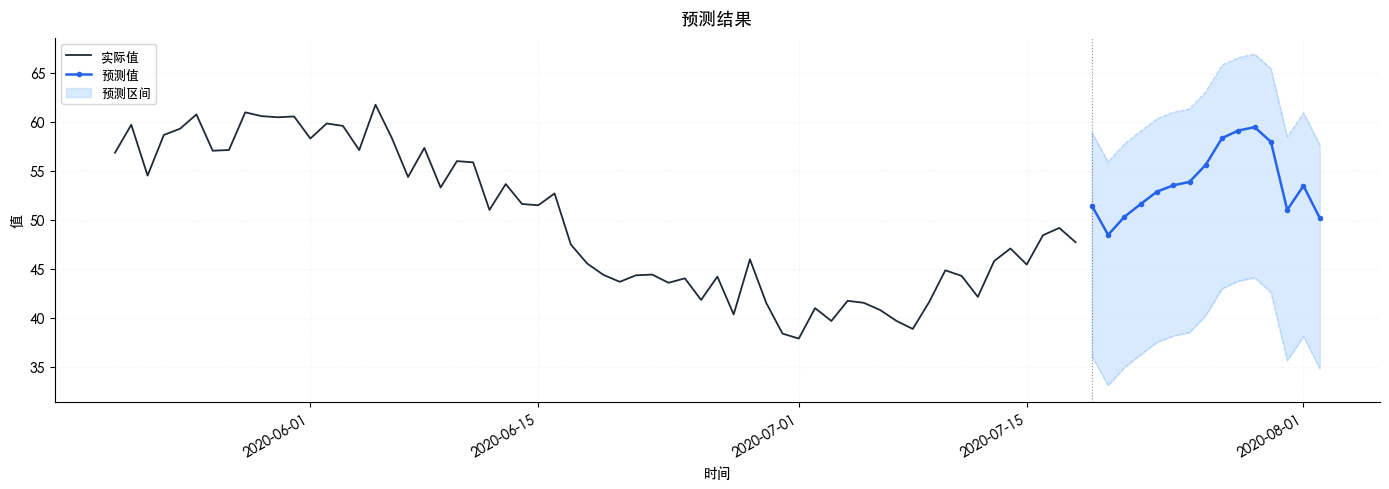

In [17]:
# One-line forecast plot / 一行代码预测图
fig = pipeline.plot(n=15, history_tail=60, lang='zh')

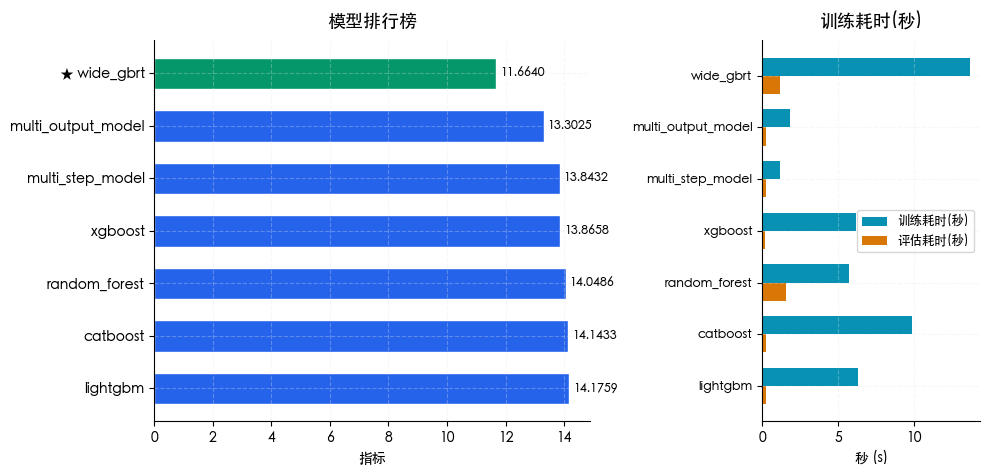

In [18]:
# Leaderboard chart / 排行榜图
fig = pipeline.plot_leaderboard(lang='zh')

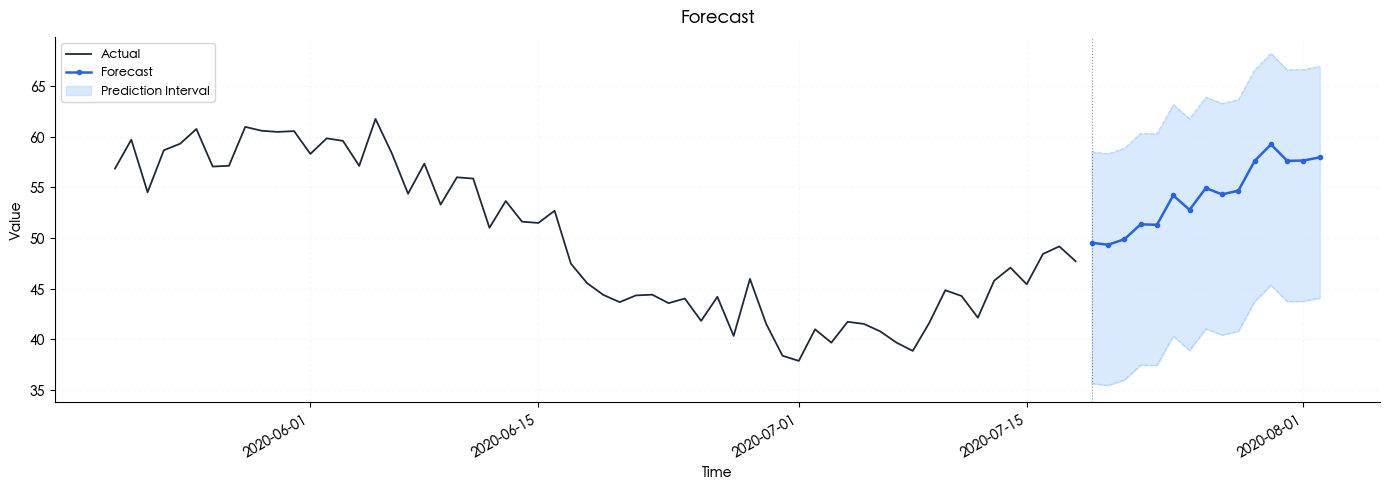

In [19]:
# Use a specific model / 指定模型
fig = pipeline.plot(n=15, model_name=second_model_name, history_tail=60, lang='en')

## 14. Error Resilience / 错误容错

If a model fails during training, the pipeline continues with remaining models.

如果某个模型在训练过程中失败，管道会继续训练其余模型。

In [20]:
# Accessing failure/skip info after fit / 拟合后访问失败/跳过信息
print(f"Failed models / 失败模型: {pipeline.failed_models}")
print(f"Skipped models / 跳过模型: {pipeline.skipped_models}")

Failed models / 失败模型: []
Skipped models / 跳过模型: []


## 15. Save & Load / 保存与加载

In [21]:
from PipelineTS.io import save_model, load_model

# save_model('my_pipeline.zip', pipeline)
# loaded = load_model('my_pipeline.zip')
# loaded.predict(10)
print("Uncomment the lines above to save/load. / 取消注释以保存/加载。")

Uncomment the lines above to save/load. / 取消注释以保存/加载。


---
# Part II: SmartRouter
# 第二部分：SmartRouter

SmartRouter is the intelligent layer on top of ModelPipeline. It automates the entire ML pipeline:

SmartRouter 是 ModelPipeline 之上的智能层，自动化整个 ML 流程：

```
Data → Profile → Preprocess → Score Models → Select Candidates
     → Screen → Explore Lags → HPO → Full Training → Ensemble → Predict
```

| Step / 步骤 | What it does / 功能 |
|---|---|
| **Data Profiling** | Analyze stationarity, trend, seasonality, noise, autocorrelation, regime changes / 分析平稳性、趋势、季节性、噪声、自相关、体制变化 |
| **Preprocessing** | Auto handle missing values, outliers, irregular frequency / 自动处理缺失值、异常值、不规则频率 |
| **Model Scoring** | Score all 26 models based on data characteristics / 基于数据特征对所有 26 个模型评分 |
| **Model Selection** | 5-category diversity: statistic, ML, NN-light, NN-medium, NN-heavy / 五类多样性选择 |
| **Quick Screening** | Fast holdout screening to eliminate weak candidates / 快速留出法筛选弱候选 |
| **Lag Exploration** | Test multiple lag windows, pick optimal / 测试多个滞后窗口，选择最优 |
| **HPO** | Optuna hyperparameter tuning per model / 每模型 Optuna 超参数调优 |
| **Full Training** | Train selected models with optimal config / 使用最优配置训练选中模型 |
| **Ensemble** | Combine top-K models (weighted avg, median, stacking, multi-stack) / 组合 top-K 模型 |

## 16. SmartRouter Basic Usage / 基本用法

In [22]:
from PipelineTS.pipeline import SmartRouter

# Minimal: just time_col and target_col
# 最简：仅需 time_col 和 target_col
router = SmartRouter(
    time_col='date',
    target_col='value',
)
router.fit(data)

pred = router.predict(n=15)
print(f"Prediction shape / 预测形状: {pred.shape}")
pred.head()


2026-02-13 11:25:32 - SmartRouter - INFO - Accelerator: MPS
2026-02-13 11:25:32 - SmartRouter - INFO - Data profile completed in 0.01s
2026-02-13 11:25:32 - SmartRouter - INFO - 
────────────────────────────────────────────────────────────
  📊 DATA PROFILE
────────────────────────────────────────────────────────────
  Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-13 11:25:32 - SmartRouter - INFO - 
────────────────────────────────────────────────────────────
  ⚙️  STRATEGY
────────────────────────────────────────────────────────────
  Lags: 6  |  Scaler: MinMaxScaler  |  GBDT diff: d=0
  Preprocessing: none
  Feature engineering: routing=adaptive, prophet_lag=True
  Selected models (5): ['tft', 'tcn', 'n_beat

Prediction shape / 预测形状: (15, 2)


,date,value
0,2020-07-11,40.370761
1,2020-07-12,39.852580
2,2020-07-13,41.528879
3,2020-07-14,43.654766
4,2020-07-15,40.648261


## 17. Presets / 预设模式

SmartRouter provides 4 quality presets that configure multiple parameters at once.

SmartRouter 提供 4 种质量预设，一次配置多个参数。

| Preset / 预设 | max_models | cv | search | ensemble |
|---|---|---|---|---|
| `'fast'` | 3 | 3 | basic | none |
| `'medium_quality'` (default) | 5 | 5 | auto | auto |
| `'high_quality'` | 8 | 5 | thorough | weighted_avg |
| `'best_quality'` | 15 | 5 | thorough | weighted_avg (top-5) |

In [23]:
# Fast preset: quick results / 快速预设：快速出结果
router_fast = SmartRouter(
    time_col='date', target_col='value',
    preset='fast',
)
router_fast.fit(data)

print(f"Models trained / 训练模型数: {len(router_fast.leader_board_)}")
print(f"Ensemble / 集成: {router_fast.ensemble_}")
router_fast.leader_board_


2026-02-13 11:36:25 - SmartRouter - INFO - Preset 'fast': max_models=3, cv=3, search=basic, ensemble=none
2026-02-13 11:36:25 - SmartRouter - INFO - Accelerator: MPS
2026-02-13 11:36:25 - SmartRouter - INFO - Data profile completed in 0.01s
2026-02-13 11:36:25 - SmartRouter - INFO - 
────────────────────────────────────────────────────────────
  📊 DATA PROFILE
────────────────────────────────────────────────────────────
  Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-13 11:36:25 - SmartRouter - INFO - 
────────────────────────────────────────────────────────────
  ⚙️  STRATEGY
────────────────────────────────────────────────────────────
  Lags: 6  |  Scaler: MinMaxScaler  |  GBDT diff: d=0
  Preprocessing: no

Models trained / 训练模型数: 3
Ensemble / 集成: None


Leaderboard,model,train_cost(s),eval_cost(s),metric
0,n_beats,46.425143,0.375499,2.961218
1,tcn,20.616870,0.374774,4.422438
2,lightgbm,3.832214,0.219040,9.415494


In [24]:
# High quality with time limit / 高质量 + 时间限制
router_hq = SmartRouter(
    time_col='date', target_col='value',
    preset='high_quality',
    time_limit=120,        # 2-minute budget / 2 分钟预算
)
router_hq.fit(data)
router_hq.leader_board_


2026-02-13 11:37:47 - SmartRouter - INFO - Preset 'high_quality': max_models=8, cv=5, search=thorough, ensemble=weighted_avg
2026-02-13 11:37:47 - SmartRouter - INFO - Accelerator: MPS
2026-02-13 11:37:47 - SmartRouter - INFO - Data profile completed in 0.01s
2026-02-13 11:37:47 - SmartRouter - INFO - 
────────────────────────────────────────────────────────────
  📊 DATA PROFILE
────────────────────────────────────────────────────────────
  Rows: 200  |  Freq: D  |  Regular: True
  Stationarity: stationary (d=0)
  Trend: 0.055  |  Seasonality: 0.883  |  Noise: 0.972
  Autocorr(1): 0.926  |  Autocorr(2): 0.914  |  CV: 0.144
  Seasonalities: 3  |  Regime changes: 32
  Missing: 0.0%  |  Outliers: 0.0%  |  Has negative: False  Dominant periods: [67, 100, 6]
2026-02-13 11:37:47 - SmartRouter - INFO - 
────────────────────────────────────────────────────────────
  ⚙️  STRATEGY
────────────────────────────────────────────────────────────
  Lags: 6  |  Scaler: MinMaxScaler  |  GBDT diff: d=0


Leaderboard,model,train_cost(s),eval_cost(s),metric
0,chronos_2_small,1.847456,0.263277,1.048658
1,deepar,14.869320,0.289252,1.715134
2,auto_arima,3.471062,0.208817,3.942756
3,catboost,2.654014,0.220487,6.229144


## 18. Data Profiling / 数据画像

After `fit()`, inspect the data profile that drove all routing decisions.

`fit()` 后，检查驱动所有路由决策的数据画像。

In [25]:
# Data profile summary / 数据画像摘要
profile = router.profile_
print(profile)

print(f"\nKey insights / 关键洞察:")
print(f"  Frequency / 频率: {profile.freq}")
print(f"  Stationarity / 平稳性: {profile.stationarity}")
print(f"  Trend strength / 趋势强度: {profile.trend_strength:.3f}")
print(f"  Seasonality strength / 季节性强度: {profile.seasonality_strength:.3f}")
print(f"  Noise ratio / 噪声比: {profile.noise_ratio:.3f}")
print(f"  Autocorr lag-1 / 滞后-1 自相关: {profile.autocorr_lag1:.3f}")
print(f"  Dominant periods / 主周期: {profile.dominant_periods}")
print(f"  Regime changes / 体制变化: {profile.regime_changes}")

DataProfile(
  n_rows=200,
  freq='D',
  freq_timedelta=Timedelta('1 days 00:00:00'),
  is_regular=True,
  dominant_periods=[67, 100, 6],
  stationarity='stationary',
  suggested_d=0,
  mean=49.92,
  std=7.168,
  cv=0.1436,
  skewness=-0.01096,
  kurtosis=-1.369,
  has_negative=False,
  pct_missing=0,
  pct_outlier=0,
  noise_ratio=0.972,
  trend_strength=0.0553,
  seasonality_strength=0.8827,
  autocorr_lag1=0.9255,
  autocorr_lag2=0.9142,
  n_seasonalities=3,
  regime_changes=32,
  n_series=1,
)

Key insights / 关键洞察:
  Frequency / 频率: D
  Stationarity / 平稳性: stationary
  Trend strength / 趋势强度: 0.055
  Seasonality strength / 季节性强度: 0.883
  Noise ratio / 噪声比: 0.972
  Autocorr lag-1 / 滞后-1 自相关: 0.926
  Dominant periods / 主周期: [67, 100, 6]
  Regime changes / 体制变化: 32


## 19. Model Scoring & Selection / 模型评分与选择

SmartRouter scores all 26 models based on data characteristics and provides transparent scoring reasons.

SmartRouter 基于数据特征对所有 26 个模型评分，并提供透明的评分原因。

In [26]:
# View model scores / 查看模型评分
scores = router.model_scores_

# Top 10 scored models / 评分前 10 的模型
top10 = sorted(scores.items(), key=lambda x: x[1]['total'], reverse=True)[:10]
for name, info in top10:
    reasons_str = ', '.join(f"{r}({d:+.0f})" for r, d in info['reasons'] if r != 'base')
    print(f"  {name:20s} score={info['total']:.0f}  [{reasons_str}]")

  tft                  score=91  [medium_series(n=200): heavy NN viable(+10), strong_seasonality(0.88): seasonal specialist(+10), strong_autocorr: attention/temporal(+5), multi_seasonal(n=3): complex pattern(+8), regime_changes: attention handles shifts(+3), GTB-capable: adaptive routing benefits complex data(+5)]
  n_beats              score=90  [medium_series(n=200): medium NN sweet spot(+12), strong_seasonality(0.88): seasonal specialist(+10), high_noise: regularized NN(+5), multi_seasonal(n=3): complex pattern(+8), GTB-capable: adaptive routing benefits complex data(+5)]
  tcn                  score=90  [medium_series(n=200): light NN good(+12), strong_seasonality: handles seasonal(+6), high_noise: regularized NN(+5), strong_autocorr(0.93): sequential model(+8), GTB-capable: adaptive routing benefits complex data(+5), tcn: local pattern specialist(+4)]
  stacking_rnn         score=90  [medium_series(n=200): medium NN sweet spot(+12), strong_seasonality: handles seasonal(+6), strong

In [27]:
# View the selected strategy / 查看选中的策略
strategy = router.strategy
print("Selected strategy / 选中策略:")
print(f"  Models / 模型: {strategy['models']}")
print(f"  Lags / 滞后: {strategy['lags']}")
print(f"  Scaler / 缩放器: {type(strategy['scaler']).__name__}")
print(f"  GBDT diff / GBDT 差分: {strategy['gbdt_differential_n']}")
print(f"  Feature engineering / 特征工程: {strategy['feature_engineering']}")

Selected strategy / 选中策略:
  Models / 模型: ['deepar', 'n_hits', 'tft', 'tcn', 'auto_arima']
  Lags / 滞后: 4
  Scaler / 缩放器: MinMaxScaler
  GBDT diff / GBDT 差分: 0
  Feature engineering / 特征工程: {'routing_mode': 'adaptive', 'prophet_use_lag_features': True, 'prophet_seasonality_mode': 'auto'}


## 20. Lag Exploration / 滞后窗口探索

When `search_strategy='auto'` or `'thorough'`, SmartRouter tests 2-3 lag candidates and picks the best via holdout evaluation.

当 `search_strategy='auto'` 或 `'thorough'` 时，SmartRouter 测试 2-3 个候选滞后窗口，通过留出验证选择最优。

In [28]:
# Lag exploration results (if applicable)
# 滞后窗口探索结果（如果有的话）
if router._lag_exploration_results:
    print("Lag exploration results / 滞后窗口探索结果:")
    for lag, metric in router._lag_exploration_results.items():
        marker = ' ← selected / 已选择' if lag == router.strategy_['lags'] else ''
        print(f"  lags={lag}: metric={metric:.4f}{marker}")
else:
    print(f"Lag was directly computed: {router.strategy_['lags']}")
    print("(Lag exploration runs with 'auto' or 'thorough' search strategy)")

Lag exploration results / 滞后窗口探索结果:


TypeError: unsupported format string passed to dict.__format__

## 21. Optuna HPO / 超参数优化

Enable Optuna-based hyperparameter optimization between lag exploration and full training.

在滞后窗口探索和完整训练之间启用基于 Optuna 的超参数优化。

In [ ]:
router_hpo = SmartRouter(
    time_col='date', target_col='value',
    preset='fast',
    hpo_strategy='quick',           # 'none', 'quick' (5 trials), 'full'
    hpo_n_trials=5,                 # Trials per model / 每模型试验数
    hpo_timeout_per_model=30,       # Max seconds per model / 每模型最大秒数
)
router_hpo.fit(data)

# View HPO results / 查看 HPO 结果
if router_hpo._hpo_results:
    print("HPO results / HPO 结果:")
    for model, info in router_hpo._hpo_results.items():
        print(f"  {model}: best_value={info.get('best_value', 'N/A')}, "
              f"n_trials={info.get('n_trials', 'N/A')}, "
              f"time={info.get('time', 'N/A'):.1f}s")
        if 'best_params' in info:
            print(f"    params: {info['best_params']}")
else:
    print("No HPO results (may require optuna installed). / 无 HPO 结果。")

## 22. Ensemble Strategies / 集成策略

SmartRouter automatically builds an ensemble of top-K models after training.

SmartRouter 在训练后自动构建 top-K 模型的集成。

| Strategy / 策略 | Description / 描述 |
|---|---|
| `'auto'` | Build ensemble when top models are close in performance / 当顶级模型性能接近时构建集成 |
| `'weighted_avg'` | Inverse-metric weighted average / 指标反比加权平均 |
| `'median'` | Median of predictions (robust to outlier models) / 预测中位数（对异常模型鲁棒） |
| `'stacking'` | Ridge meta-learner on cross-validated predictions / 在交叉验证预测上的 Ridge 元学习器 |
| `'multi_stack'` | Two-layer stacking (Ridge + ElasticNet + blend) / 两层堆叠 |
| `'none'` | No ensemble, use single best model / 不集成，使用单个最佳模型 |

In [ ]:
# Weighted average ensemble / 加权平均集成
router_ens = SmartRouter(
    time_col='date', target_col='value',
    max_models=4,
    ensemble_strategy='weighted_avg',
    ensemble_top_k=3,
)
router_ens.fit(data)

if router_ens.ensemble_:
    print(f"Ensemble / 集成: {router_ens.ensemble_}")
    print(f"Weights / 权重: {router_ens.ensemble_.weights}")
else:
    print("No ensemble built (models too far apart). / 未构建集成。")

In [ ]:
# Compare ensemble vs single best / 对比集成 vs 单最佳
pred_ensemble = router_ens.predict(n=10, use_ensemble=True)
pred_single = router_ens.predict(n=10, use_ensemble=False)

print("Ensemble prediction / 集成预测:", pred_ensemble['value'].values[:5].round(2))
print("Single best / 单最佳:         ", pred_single['value'].values[:5].round(2))

In [ ]:
# Multi-layer stacking / 多层堆叠
router_ms = SmartRouter(
    time_col='date', target_col='value',
    max_models=4,
    ensemble_strategy='multi_stack',
    ensemble_top_k=3,
)
router_ms.fit(data)

print(f"Multi-stack ensemble / 多层堆叠集成: {router_ms.ensemble_}")
router_ms.predict(5).head()

## 23. Search Strategies / 搜索策略

| Strategy / 策略 | Quick Screen | Lag Exploration | Description / 描述 |
|---|---|---|---|
| `'basic'` | No | No | Fastest: direct scoring → train / 最快：直接评分 → 训练 |
| `'auto'` | Yes | Yes | Balanced: screen + explore lags / 平衡：筛选 + 探索滞后 |
| `'thorough'` | Yes | Yes (broader) | Most thorough search / 最全面搜索 |

In [ ]:
# Thorough search / 全面搜索
router_thorough = SmartRouter(
    time_col='date', target_col='value',
    search_strategy='thorough',
    max_models=4,
)
router_thorough.fit(data)

# Screening results / 筛选结果
if router_thorough._screening_results:
    print("Screening results / 筛选结果:")
    for m, metric in router_thorough._screening_results:
        survived = '✓' if m in router_thorough.strategy_['models'] else '✗'
        print(f"  {survived} {m}: {metric:.4f}")

router_thorough.leader_board_

## 24. SmartRouter with Panel Data & Covariates / 面板数据与协变量

In [ ]:
# SmartRouter with panel data / 面板数据
router_panel = SmartRouter(
    time_col='date', target_col='value',
    id_col='store',
    preset='fast',
)
router_panel.fit(panel_data)

print(f"Profiled {router_panel.profile_.n_series} series")
router_panel.predict(5).head(10)

In [ ]:
# SmartRouter with covariates / 协变量
router_cov = SmartRouter(
    time_col='date', target_col='value',
    known_covariates=['holiday'],
    past_covariates=['temperature'],
    preset='fast',
)
router_cov.fit(cov_data)

future = pd.DataFrame({'holiday': [0, 0, 0, 1, 0]})
router_cov.predict(5, future_covariates=future)

## 25. SmartRouter Visualization & Update / 可视化与增量更新

In [ ]:
# One-line forecast plot / 一行预测图
router.plot(n=15, history_tail=60, lang='zh')

In [ ]:
# Leaderboard / 排行榜
router.plot_leaderboard(lang='zh')

In [ ]:
# Incremental update / 增量更新
new_data = pd.DataFrame({
    'date': pd.date_range('2020-07-19', periods=30, freq='D'),
    'value': 50 + 10 * np.sin(np.linspace(6*np.pi, 7*np.pi, 30)) + np.random.randn(30)*2
})

router.update(new_data)
print("After SmartRouter update / SmartRouter 更新后:")
router.predict(5).head()

## 26. Full Production Example / 完整生产示例

A real-world pattern: high-quality fit → predict → save → load → incremental update.

真实世界模式：高质量训练 → 预测 → 保存 → 加载 → 增量更新。

In [ ]:
from PipelineTS.pipeline import SmartRouter
from PipelineTS.dataset import LoadElectricDataSets

# 1. Load real data / 加载真实数据
electric = LoadElectricDataSets()
electric['date'] = pd.to_datetime(electric['date'])
print(f"Electric dataset: {electric.shape}")

# 2. Smart routing with high quality preset / 智能路由 + 高质量预设
router_prod = SmartRouter(
    time_col='date',
    target_col='value',
    preset='fast',               # Use 'high_quality' for production / 生产环境用 'high_quality'
    quantile=0.9,                # 90% prediction intervals / 90% 预测区间
    time_limit=60,               # 1-minute budget / 1 分钟预算
)
router_prod.fit(electric)

# 3. Review what SmartRouter decided / 查看 SmartRouter 的决策
print(f"\nStrategy / 策略:")
print(f"  Models / 模型: {router_prod.strategy_['models']}")
print(f"  Lags / 滞后: {router_prod.strategy_['lags']}")
print(f"  Ensemble / 集成: {router_prod.ensemble_}")

# 4. Predict / 预测
forecast = router_prod.predict(n=12)
print(f"\nForecast shape / 预测形状: {forecast.shape}")
forecast.head()

In [ ]:
# 5. Visualize / 可视化
router_prod.plot(n=12, history_tail=60, lang='zh')

In [ ]:
router_prod.plot_leaderboard(lang='zh')

## Summary / 总结

### ModelPipeline vs SmartRouter / 对比

| Feature / 功能 | ModelPipeline | SmartRouter |
|---|---|---|
| **User control / 用户控制** | Full manual control / 完全手动控制 | Automatic (can override) / 自动（可覆盖） |
| **Model selection / 模型选择** | User specifies / 用户指定 | Data-driven scoring / 数据驱动评分 |
| **Preprocessing / 预处理** | User provides scaler / 用户提供缩放器 | Auto-selected / 自动选择 |
| **Lags / 滞后窗口** | User specifies / 用户指定 | Auto-explored / 自动探索 |
| **Hyperparameters / 超参数** | Manual / `__` syntax / 手动 | Auto-tuned (HPO) / 自动调优 |
| **Ensemble / 集成** | No | Yes (5 strategies) / 是（5 种策略） |
| **Best for / 最适合** | Expert users, custom workflows / 专家用户 | Quick starts, production / 快速启动、生产环境 |

### Key Parameters / 关键参数

**ModelPipeline:**
| Parameter / 参数 | Description / 描述 |
|---|---|
| `lags` | Input window size / 输入窗口 |
| `include_models` | `'light'`, `'ml'`, `'nn'`, `'all'`, or list / 模型集合 |
| `quantile` | Coverage level for intervals / 区间覆盖水平 |
| `id_col` | Panel data identifier / 面板数据标识 |
| `known_covariates` / `past_covariates` | External features / 外部特征 |
| `time_limit` | Time budget in seconds / 时间预算 |
| `cv` | Cross-validation folds / 交叉验证折数 |

**SmartRouter (additional):**
| Parameter / 参数 | Description / 描述 |
|---|---|
| `preset` | `'fast'`, `'medium_quality'`, `'high_quality'`, `'best_quality'` |
| `ensemble_strategy` | `'auto'`, `'weighted_avg'`, `'median'`, `'stacking'`, `'multi_stack'`, `'none'` |
| `ensemble_top_k` | Max models in ensemble / 集成最大模型数 |
| `search_strategy` | `'basic'`, `'auto'`, `'thorough'` |
| `hpo_strategy` | `'none'`, `'quick'`, `'full'` |
| `max_models` | Max candidate models / 最大候选模型数 |